# Testes com Algoritmo KNN (K-Nearest Neighbors)

Este notebook é utilizado para a realização de testes no algoritmo KNN,  com o objetivo de demonstrar seu funcionamento em diferentes datasets.

## Funcionamento do KNN

Dado um conjunto de elementos de parâmetro, ao fornecer um novo dado `x` , o KNN obtém até `K` elementos mais próximos de `x` e o classifica conforme a pluralidade dos elementos mais próximos deste, conforme pode ser visualizado abaixo: 

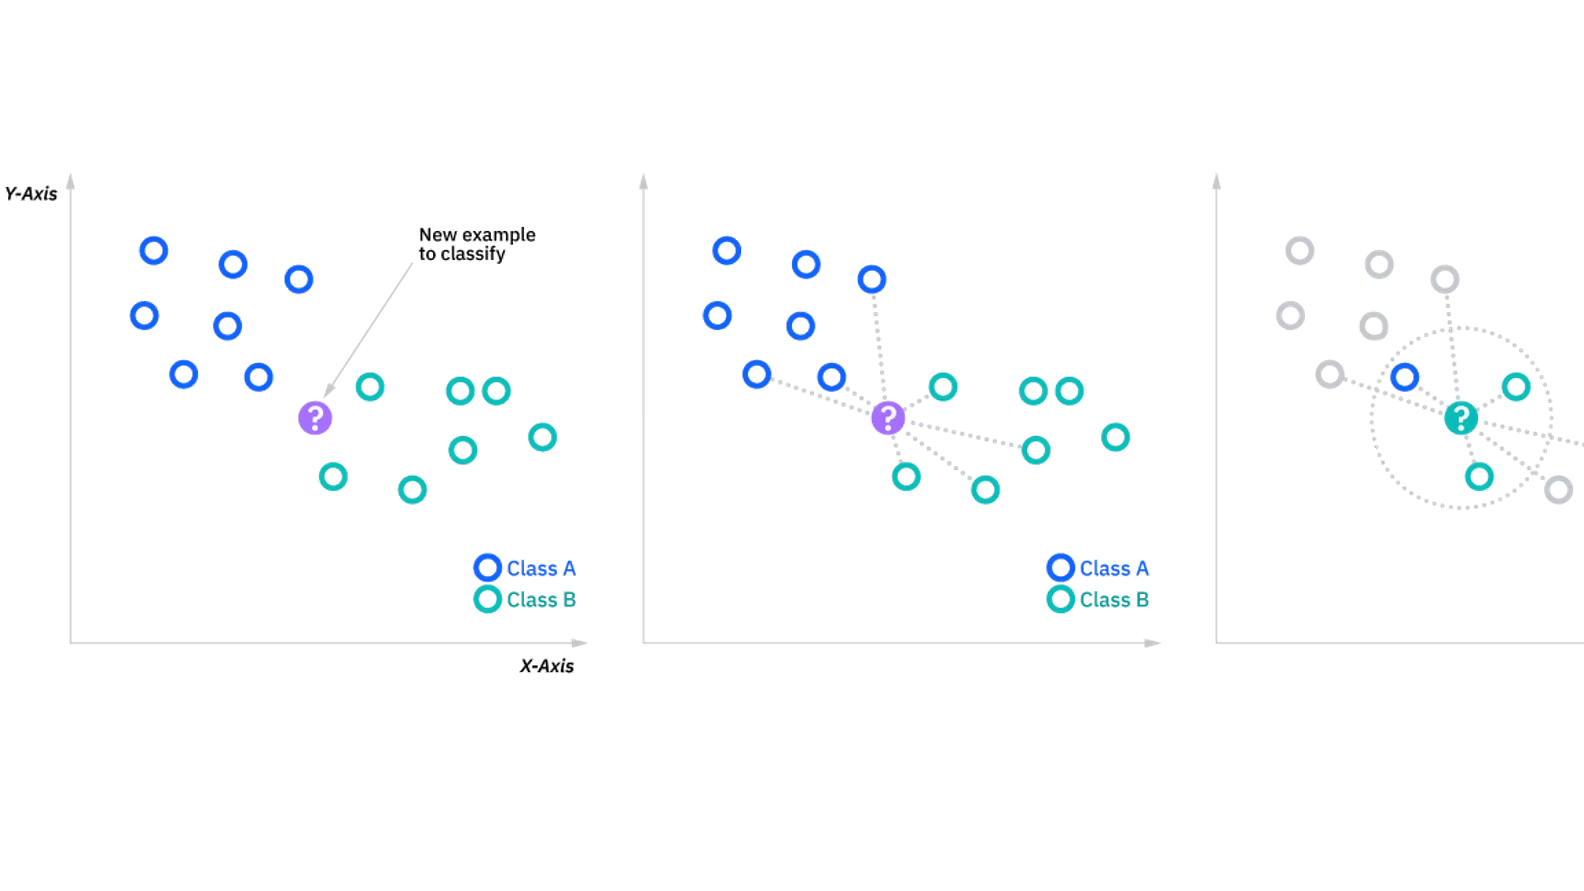


---

> Execute as células sequencialmente para garantir o funcionamento correto deste notebook.
>
> Isto garante que os módulos utilizados e os datasets de treinamento declarados estejam devidamente computados antes da execução
> do algoritmo.

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
import numpy as np

from src.knn import KNN

from src.distances import (
    euclidean_distance,
    manhattan_distance,
    minkowski_distance
)

from src.metrics import knn_accuracy

samples = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7],
    [8, 6]
])

features = np.array([
    "A",
    "A",
    "A",
    "B",
    "B",
    "B"
])

test_samples = np.array([
    [2, 2],
    [4, 4],
    [7, 6],
    [8, 8]
])

test_feats = np.array([
    "A",
    "A",
    "B",
    "B"
])

## Teste das Distâncias
Aqui serão feitos testes e comparações das distâncias calculadas

### Fórmula Distância Euclidiana
![Euclidean Distance](../images/euclidian.png)

Fonte: https://towardsdatascience.com/optimising-pairwise-euclidean-distance-calculations-using-python-fc020112c984/

### Fórmula Distância de Manhattan
![Manhattan Distance](../images/manhattan.png)

Fonte: https://medidassimdist.wordpress.com/distancia-de-manhattan/

### Fórmula Distância de Minkowski
![Minkowski Distance](../images/minkowski.png)

Fonte: https://aiml.com/what-is-minkowski-distance/

In [ ]:
distance_metrics = {
    "Distância Euclidiana": euclidean_distance,
    "Distância de Manhattan": manhattan_distance,
    "Distância de Minkowski": lambda x, y: minkowski_distance(x, y, order=3)
}

for metric, distance_formula in distance_metrics.items():
    model = KNN(distance_formula, neighbors=3)

    model.fit(samples, features)

    result = model.predict(test_samples)

    print(f"=== {metric} ===")

    for i in range(len(test_samples)):
        print(
            f"""
            Ponto: {test_samples[i]}
            Atributo Esperado: {test_feats[i]}
            Atributo Previsto: {result[i]}
            """
        )

    accuracy_score = knn_accuracy(
        expected_feats=test_feats,
        predicted_feats=result
    )
    
    print(f"Precisão: {accuracy_score:.2f}\n")